In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('Housing.csv')

In [3]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [4]:
# Handlig Missing rows

missing = df.isnull().sum()
missing

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [5]:
# Checking Duplicate rows
duplicates = df.duplicated().sum()

print(f"The number of duplicates values in the dataset is : {duplicates}")

The number of duplicates values in the dataset is : 0


In [6]:
for col in df.columns:
    print(f"Datatype of column {col} is : {df[col].dtypes}")

Datatype of column price is : int64
Datatype of column area is : int64
Datatype of column bedrooms is : int64
Datatype of column bathrooms is : int64
Datatype of column stories is : int64
Datatype of column mainroad is : str
Datatype of column guestroom is : str
Datatype of column basement is : str
Datatype of column hotwaterheating is : str
Datatype of column airconditioning is : str
Datatype of column parking is : int64
Datatype of column prefarea is : str
Datatype of column furnishingstatus is : str


In [7]:
# Splitting features into categorical and numerical
cat_col = []
num_col = []

for col in df.columns:
    if df[col].dtype != 'int64':
        cat_col.append(col)
    else:
        num_col.append(col)

print(f"The numerical cols are : {num_col}")
print(f"The categorical columns are : {cat_col}")

The numerical cols are : ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']
The categorical columns are : ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']


In [8]:
df['furnishingstatus'].value_counts()

furnishingstatus
semi-furnished    227
unfurnished       178
furnished         140
Name: count, dtype: int64

In [9]:
# Filling hte yes / no columns
bool_map = {
    'yes' : 1,
    'no' : 0
}
bool_col = [col for col in cat_col if col != 'furnishingstatus']
for col in bool_col:
    df[col] = df[col].map(bool_map)

In [10]:
# Applying label encoding over the 'furnishingstatus' feature

furnish_map = {
    'unfurnished' : 0,
    'semi-furnished' : 1,
    'furnished' : 2
}
df['furnishingstatus'] = df['furnishingstatus'].map(furnish_map)

In [11]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,2
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,2
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,2
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,2


# Supervised Learning

### Linear Regression 

In [12]:
lin_df = df.copy()

In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.linear_model import Lasso
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, r2_score

> Plot the PDF distribution plot of each feature 

In [14]:
def plot_pdf(df, cols=None):
    plt.style.use('dark_background')

    # if cols passed use them, else use all numeric columns
    if cols is not None:
        num_cols = [cols] if isinstance(cols, str) else cols
    else:
        num_cols = df.select_dtypes(include='number').columns.tolist()
    
    n = len(num_cols)
    grid_cols = 3
    rows = (n + grid_cols - 1) // grid_cols

    fig, axes = plt.subplots(rows, grid_cols, figsize=(grid_cols * 6, rows * 4))
    fig.patch.set_facecolor('#0f0f1a')
    axes = axes.flatten()

    for i, col in enumerate(num_cols):
        axes[i].set_facecolor('#1a1a2e')
        sns.histplot(df[col], kde=True, ax=axes[i], color='#a78bfa')
        axes[i].set_title(f"PDF of {col}", color='white', fontsize=12)
        axes[i].set_xlabel(col, color='#a0a0c0')
        axes[i].set_ylabel('Density', color='#a0a0c0')
        axes[i].tick_params(colors='white')
        axes[i].spines['bottom'].set_color('#2a2a45')
        axes[i].spines['left'].set_color('#2a2a45')
        axes[i].spines['top'].set_color('#2a2a45')
        axes[i].spines['right'].set_color('#2a2a45')
        axes[i].grid(color='#2a2a45', linestyle='--', linewidth=0.5)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('PDF of All Numeric Features',
                 color='white', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

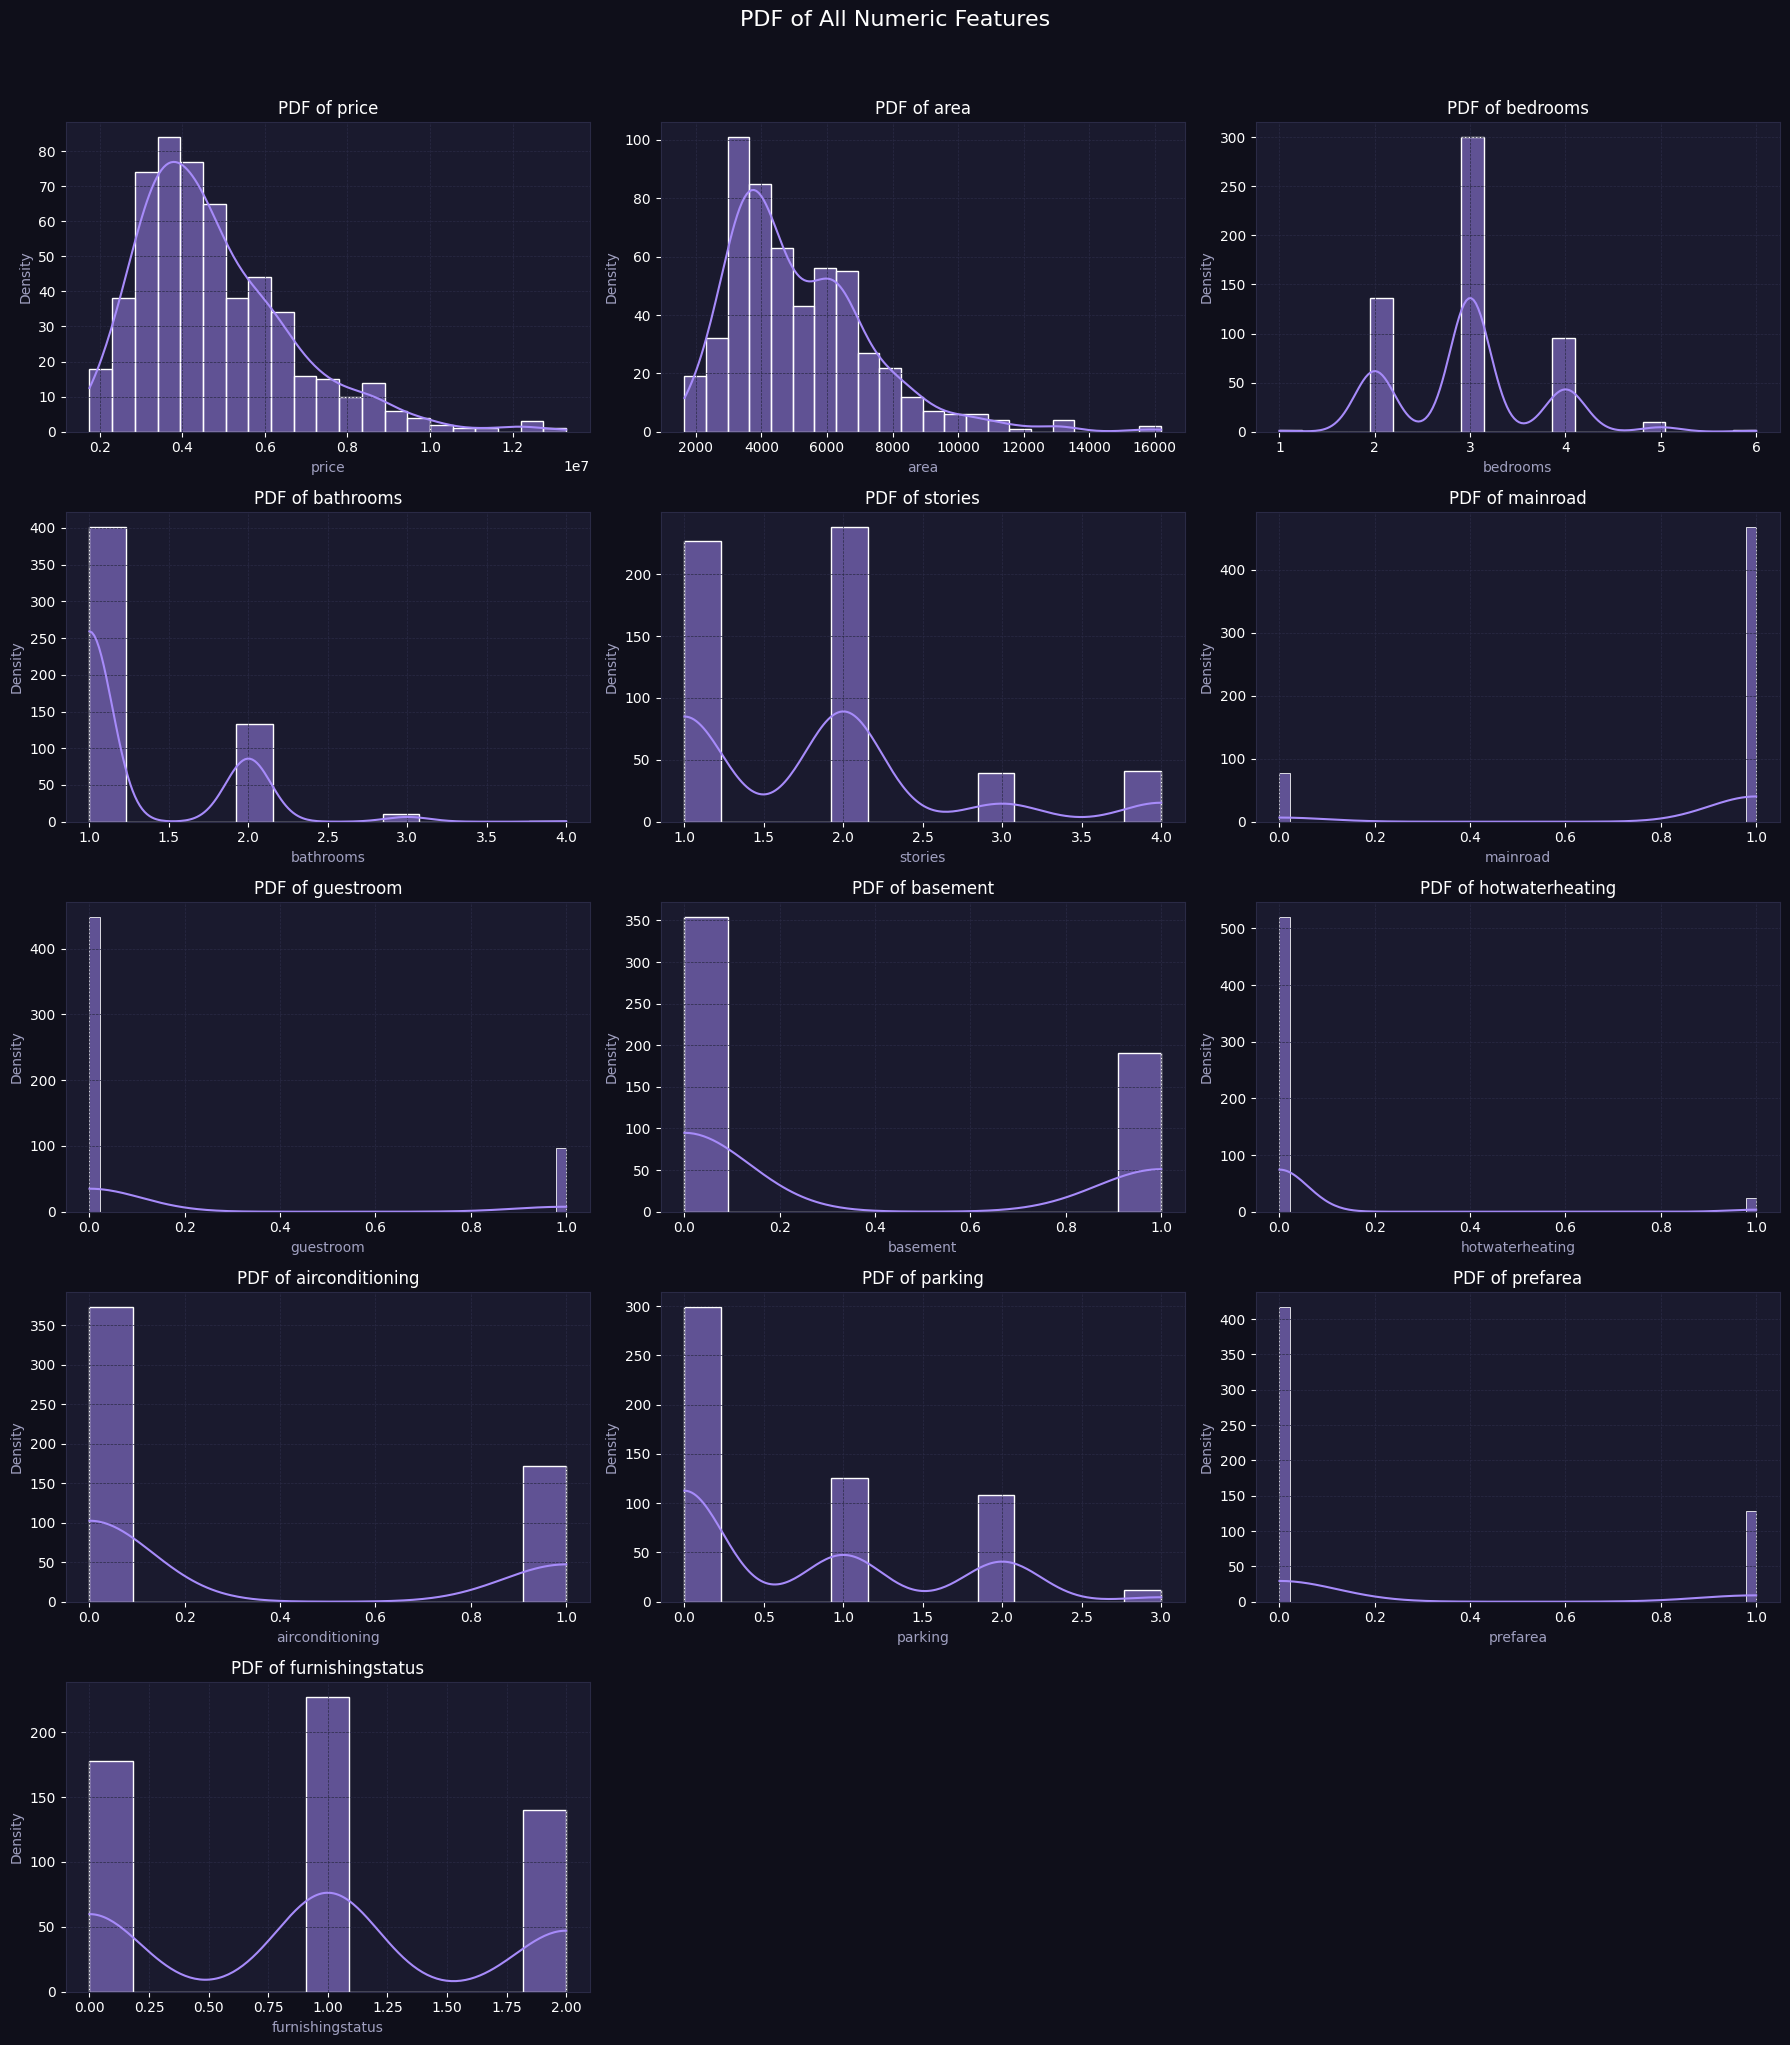

In [15]:
plot_pdf(lin_df)

In [16]:
lin_df['area'].describe()

count      545.000000
mean      5150.541284
std       2170.141023
min       1650.000000
25%       3600.000000
50%       4600.000000
75%       6360.000000
max      16200.000000
Name: area, dtype: float64

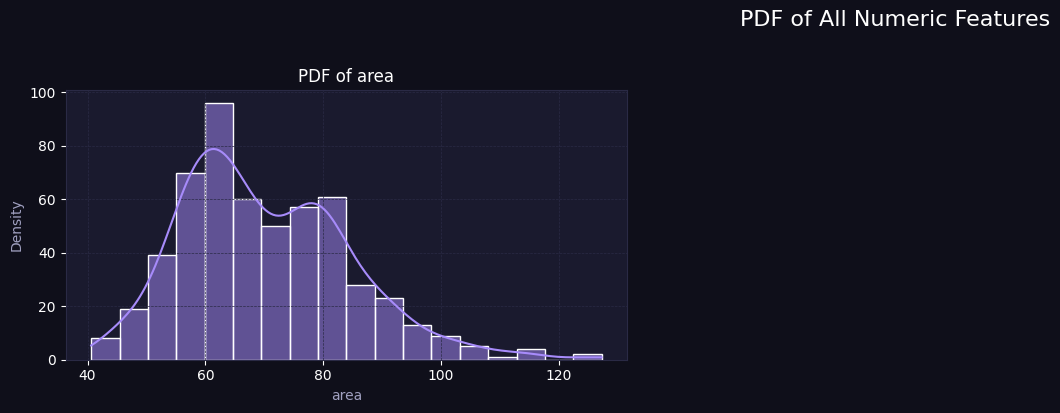

In [17]:
# Applying Scaling 
lin_df['area'] = np.sqrt(lin_df['area'])

plot_pdf(lin_df, 'area')

In [18]:
scaler = StandardScaler()
lin_df['area'] = scaler.fit_transform(lin_df[['area']])

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    lin_df.drop('price', axis=1), 
    lin_df['price'], 
    test_size=0.2, 
    random_state=42
)
lr = LinearRegression()

In [20]:
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
r2 = r2_score(y_test, y_pred)

print(f"R2 score of the model : {r2}")

R2 score of the model : 0.6493251561552948


In [21]:
lasso = Lasso(alpha=0.9)
lasso.fit(X_train, y_train)

# Evaluate
print("R2 Score:", r2_score(y_test, lasso.predict(X_test)))

R2 Score: 0.6493244954786364


---

### Decision Tree

In [22]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    df.drop('price', axis=1), 
    df['price'], 
    test_size=0.2, 
    random_state=42
)
dt = DecisionTreeRegressor(random_state=42)

In [24]:
param_grid = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(
    dt,
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

In [25]:
grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_

print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)
print("Test R2 Score:", r2_score(y_test, best_model.predict(X_test)))

Best Parameters: {'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2}
Best CV Score: 0.5416068141740019
Test R2 Score: 0.48605368046836084


### Random Forest Model

In [26]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In [27]:
# Train model
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 8, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}
grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

In [28]:
X = df.drop(columns=['price']) 
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [29]:
grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


In [30]:
print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)
print("Test R2 Score:", r2_score(y_test, best_model.predict(X_test)))

Best Parameters: {'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV Score: 0.6455081457921727
Test R2 Score: 0.618499326228424


### XG Boost Model

In [31]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In [33]:
X = df.drop(columns=['price'])
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
) 


In [36]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

grid_search = GridSearchCV(
    XGBRegressor(random_state=42),
    param_grid,
    cv=3,         
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

In [37]:
grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_

print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)
print("Test R2 Score:", r2_score(y_test, best_model.predict(X_test)))

Fitting 3 folds for each of 32 candidates, totalling 96 fits
Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.8}
Best CV Score: 0.6324330766995748
Test R2 Score: 0.6286870241165161


## K MEAN CLUSTERING

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler 

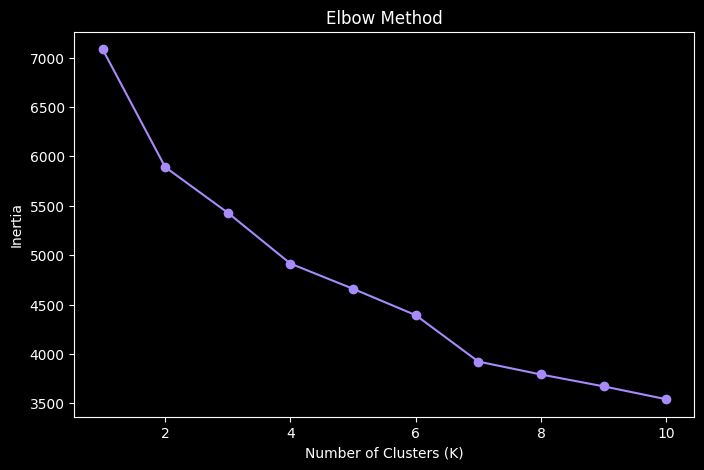

In [38]:
# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# Find optimal number of clusters (Elbow Method)
inertia = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot elbow curve
plt.style.use('dark_background')
plt.figure(figsize=(8, 5))
plt.plot(K, inertia, 'o-', color='#a78bfa')
plt.xlabel('Number of Clusters (K)', color='white')
plt.ylabel('Inertia', color='white')
plt.title('Elbow Method', color='white')
plt.show()



In [39]:
k = 3   # From plot

kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(X_scaled) 

df['Cluster'] = kmeans.labels_
print(df['Cluster'].value_counts())

Cluster
1    307
0    125
2    113
Name: count, dtype: int64
